In [2]:
import pandas as pd

# Replace with your actual filename (check the left sidebar 📁 in Colab)
f = "globalterrorismdb_0718dist.csv"   # <-- edit if the name differs

df = pd.read_csv(f, encoding="latin-1", low_memory=False) if f.endswith(".csv") \
     else pd.read_excel(f)

print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
df.head(3)

Shape: (25487, 135)

Columns: ['eventid', 'iyear', 'imonth', 'iday', 'approxdate', 'extended', 'resolution', 'country', 'country_txt', 'region', 'region_txt', 'provstate', 'city', 'latitude', 'longitude', 'specificity', 'vicinity', 'location', 'summary', 'crit1', 'crit2', 'crit3', 'doubtterr', 'alternative', 'alternative_txt', 'multiple', 'success', 'suicide', 'attacktype1', 'attacktype1_txt', 'attacktype2', 'attacktype2_txt', 'attacktype3', 'attacktype3_txt', 'targtype1', 'targtype1_txt', 'targsubtype1', 'targsubtype1_txt', 'corp1', 'target1', 'natlty1', 'natlty1_txt', 'targtype2', 'targtype2_txt', 'targsubtype2', 'targsubtype2_txt', 'corp2', 'target2', 'natlty2', 'natlty2_txt', 'targtype3', 'targtype3_txt', 'targsubtype3', 'targsubtype3_txt', 'corp3', 'target3', 'natlty3', 'natlty3_txt', 'gname', 'gsubname', 'gname2', 'gsubname2', 'gname3', 'gsubname3', 'motive', 'guncertain1', 'guncertain2', 'guncertain3', 'individual', 'nperps', 'nperpcap', 'claimed', 'claimmode', 'claimmode_txt', 

,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
0,197000000001,1970,7,2,NaN,0,NaN,58,Dominican Republic,2,...,NaN,NaN,NaN,NaN,PGIS,0.0,0.0,0.0,0.0,NaN
1,197000000002,1970,0,0,NaN,0,NaN,130,Mexico,1,...,NaN,NaN,NaN,NaN,PGIS,0.0,1.0,1.0,1.0,NaN
2,197001000001,1970,1,0,NaN,0,NaN,160,Philippines,5,...,NaN,NaN,NaN,NaN,PGIS,-9.0,-9.0,1.0,1.0,NaN


In [4]:
# ── Step 1: Initial assessment ────────────────────────────────
print("Shape (rows, columns):", df.shape)

print("\n=== Data types breakdown ===")
print(df.dtypes.value_counts())

print("\n=== Missing values (top 20 columns) ===")
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
print(summary.head(20))

Shape (rows, columns): (25487, 135)

=== Data types breakdown ===
float64    60
object     57
int64      18
Name: count, dtype: int64

=== Missing values (top 20 columns) ===
                  missing_count  missing_pct
gsubname3                 25487        100.0
claimmode3_txt            25486        100.0
claim3                    25486        100.0
ransompaidus              25486        100.0
claimmode3                25486        100.0
gsubname2                 25486        100.0
ransomamtus               25486        100.0
attacktype3_txt           25485        100.0
attacktype3               25485        100.0
gname3                    25484        100.0
guncertain3               25484        100.0
ransomnote                25482        100.0
claimmode2                25476        100.0
claimmode2_txt            25476        100.0
claim2                    25475        100.0
approxdate                25466         99.9
corp3                     25465         99.9
compclaim      

In [5]:
# ── Step 2: Select core columns + check their completeness ────
core_cols = [
    "iyear", "imonth", "iday",          # when
    "country_txt", "region_txt",        # where (country/region)
    "city", "latitude", "longitude",    # where (precise)
    "attacktype1_txt",                  # how
    "targtype1_txt",                    # who/what was targeted
    "gname",                            # who did it
    "weaptype1_txt",                    # weapon
    "nkill", "nwound",                  # casualties
    "success", "suicide",               # outcome flags
]

core = df[core_cols]

print("Core subset shape:", core.shape)
print("\n=== Missing values in core columns ===")
miss = core.isnull().sum()
miss_pct = (miss / len(core) * 100).round(1)
print(pd.DataFrame({"missing": miss, "pct": miss_pct}).sort_values("missing", ascending=False))

Core subset shape: (25487, 16)

=== Missing values in core columns ===
                 missing   pct
nwound              6641  26.1
nkill               4968  19.5
latitude            1262   5.0
longitude           1262   5.0
gname                  1   0.0
weaptype1_txt          1   0.0
iyear                  0   0.0
imonth                 0   0.0
region_txt             0   0.0
city                   0   0.0
iday                   0   0.0
country_txt            0   0.0
attacktype1_txt        0   0.0
targtype1_txt          0   0.0
success                0   0.0
suicide                0   0.0


In [6]:
# ── Step 3: Clean the data ────────────────────────────────────
# Rename to friendlier names
col_map = {
    "iyear": "year", "imonth": "month", "iday": "day",
    "country_txt": "country", "region_txt": "region",
    "city": "city", "latitude": "latitude", "longitude": "longitude",
    "attacktype1_txt": "attack_type", "targtype1_txt": "target_type",
    "gname": "group_name", "weaptype1_txt": "weapon_type",
    "nkill": "killed", "nwound": "wounded",
    "success": "success", "suicide": "suicide",
}
data = core.rename(columns=col_map).copy()

# 1) Casualties: blank means none recorded → 0, and make them integers
data["killed"]  = pd.to_numeric(data["killed"],  errors="coerce").fillna(0).astype(int)
data["wounded"] = pd.to_numeric(data["wounded"], errors="coerce").fillna(0).astype(int)

# 2) Single text gaps → "Unknown"
data["group_name"]  = data["group_name"].fillna("Unknown")
data["weapon_type"] = data["weapon_type"].fillna("Unknown")

# 3) Build a real date column (GTD uses 0 for unknown month/day → map to 1)
data["date"] = pd.to_datetime(
    dict(year=data["year"],
         month=data["month"].replace(0, 1),
         day=data["day"].replace(0, 1)),
    errors="coerce"
)

# 4) Engineered feature: total casualties
data["casualties"] = data["killed"] + data["wounded"]

print("Cleaned shape:", data.shape)
print("\n=== Remaining missing values ===")
print(data.isnull().sum())
print("\n=== Data types ===")
print(data.dtypes)
data.head()

Cleaned shape: (25487, 18)

=== Remaining missing values ===
year              0
month             0
day               0
country           0
region            0
city              0
latitude       1262
longitude      1262
attack_type       0
target_type       0
group_name        0
weapon_type       0
killed            0
wounded           0
success           0
suicide           0
date              0
casualties        0
dtype: int64

=== Data types ===
year                    int64
month                   int64
day                     int64
country                object
region                 object
city                   object
latitude              float64
longitude             float64
attack_type            object
target_type            object
group_name             object
weapon_type            object
killed                  int64
wounded                 int64
success                 int64
suicide                 int64
date           datetime64[ns]
casualties              int64
dtype:

,year,month,day,country,region,city,latitude,longitude,attack_type,target_type,group_name,weapon_type,killed,wounded,success,suicide,date,casualties
0,1970,7,2,Dominican Republic,Central America & Caribbean,Santo Domingo,18.456792,-69.951164,Assassination,Private Citizens & Property,MANO-D,Unknown,1,0,1,0,1970-07-02,1
1,1970,0,0,Mexico,North America,Mexico city,19.371887,-99.086624,Hostage Taking (Kidnapping),Government (Diplomatic),23rd of September Communist League,Unknown,0,0,1,0,1970-01-01,0
2,1970,1,0,Philippines,Southeast Asia,Unknown,15.478598,120.599741,Assassination,Journalists & Media,Unknown,Unknown,1,0,1,0,1970-01-01,1
3,1970,1,0,Greece,Western Europe,Athens,37.997490,23.762728,Bombing/Explosion,Government (Diplomatic),Unknown,Explosives,0,0,1,0,1970-01-01,0
4,1970,1,0,Japan,East Asia,Fukouka,33.580412,130.396361,Facility/Infrastructure Attack,Government (Diplomatic),Unknown,Incendiary,0,0,1,0,1970-01-01,0


In [7]:
# ── Step 4: Transformation (one-hot encoding + standardization) ──
from sklearn.preprocessing import StandardScaler

# --- 4a) One-hot encode 'region' ---
# region has only ~12 categories, so one-hot is clean and readable.
region_dummies = pd.get_dummies(data["region"], prefix="region")
print("One-hot encoding of 'region' →", region_dummies.shape[1], "new columns")
print(region_dummies.head())

# --- 4b) Standardize numeric features (mean 0, std 1) ---
num_cols = ["killed", "wounded", "casualties"]
scaler = StandardScaler()
scaled = pd.DataFrame(
    scaler.fit_transform(data[num_cols]),
    columns=[c + "_scaled" for c in num_cols],
    index=data.index,
)
print("\nStandardized numeric features (should be mean≈0, std≈1):")
print(scaled.describe().round(2))

# --- Combine everything into one analysis-ready frame ---
data_encoded = pd.concat([data, region_dummies, scaled], axis=1)
print("\nFinal encoded shape:", data_encoded.shape)

One-hot encoding of 'region' → 11 new columns
   region_Australasia & Oceania  region_Central America & Caribbean  \
0                         False                                True   
1                         False                               False   
2                         False                               False   
3                         False                               False   
4                         False                               False   

   region_East Asia  region_Eastern Europe  region_Middle East & North Africa  \
0             False                  False                              False   
1             False                  False                              False   
2             False                  False                              False   
3             False                  False                              False   
4              True                  False                              False   

   region_North America  region_South Am

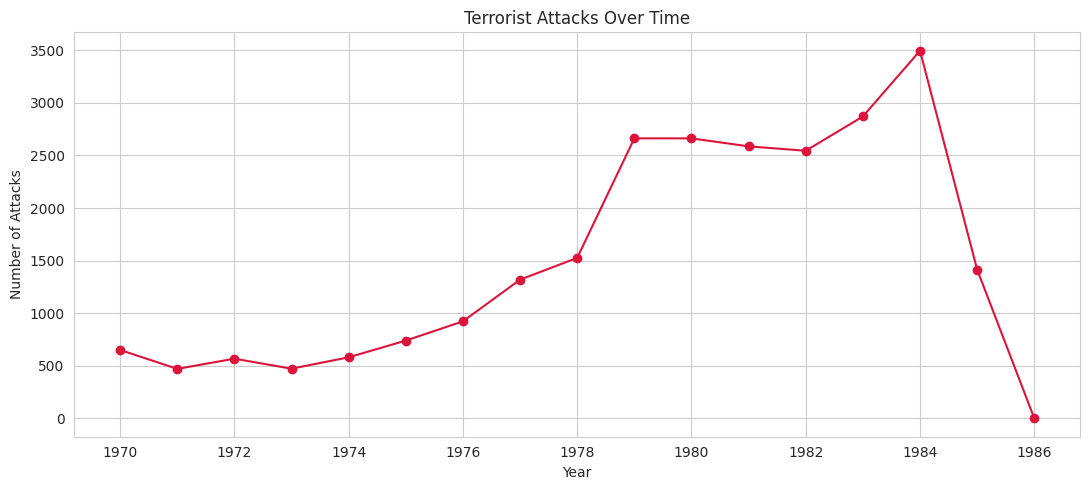

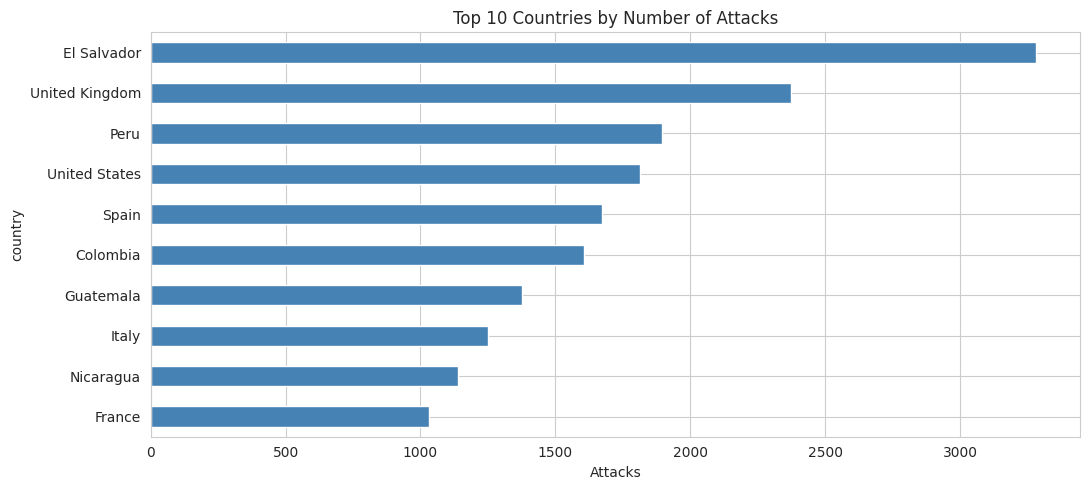

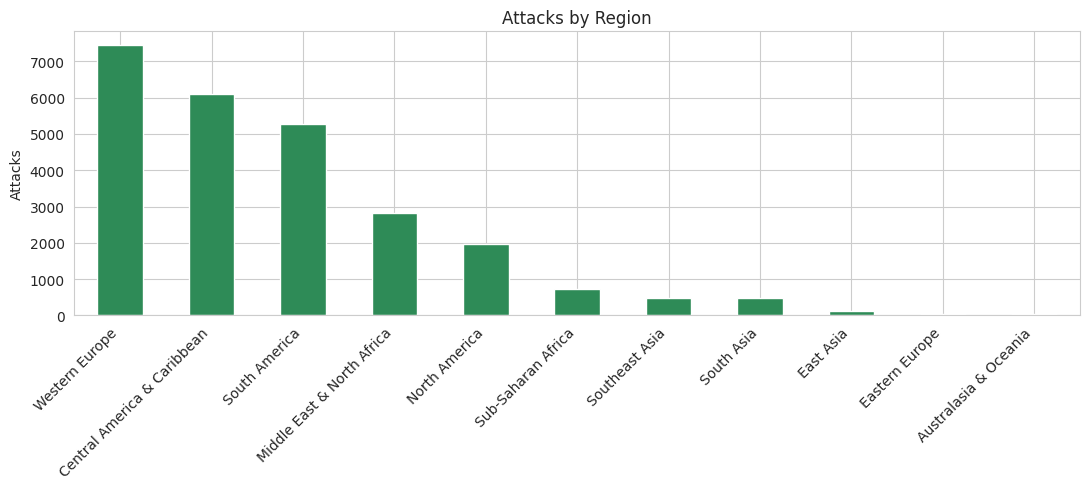

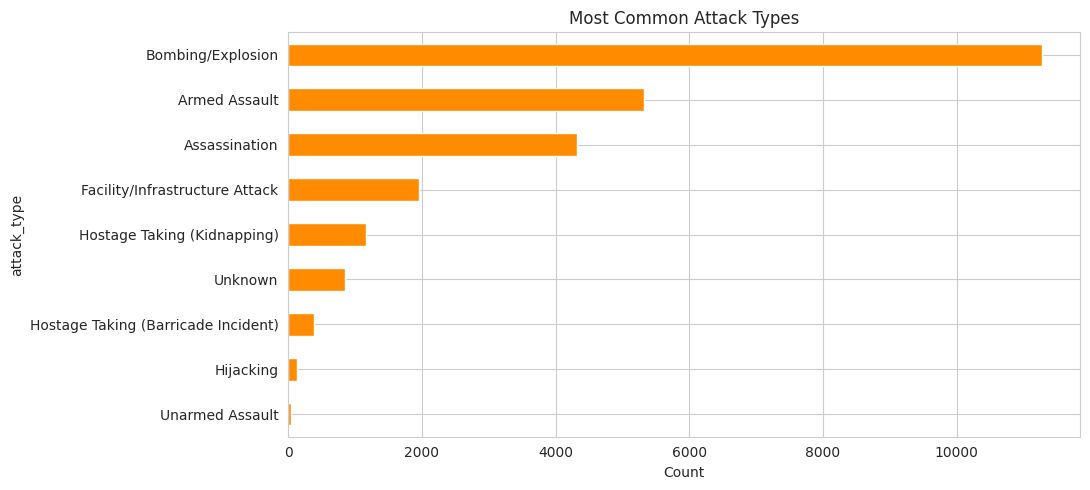

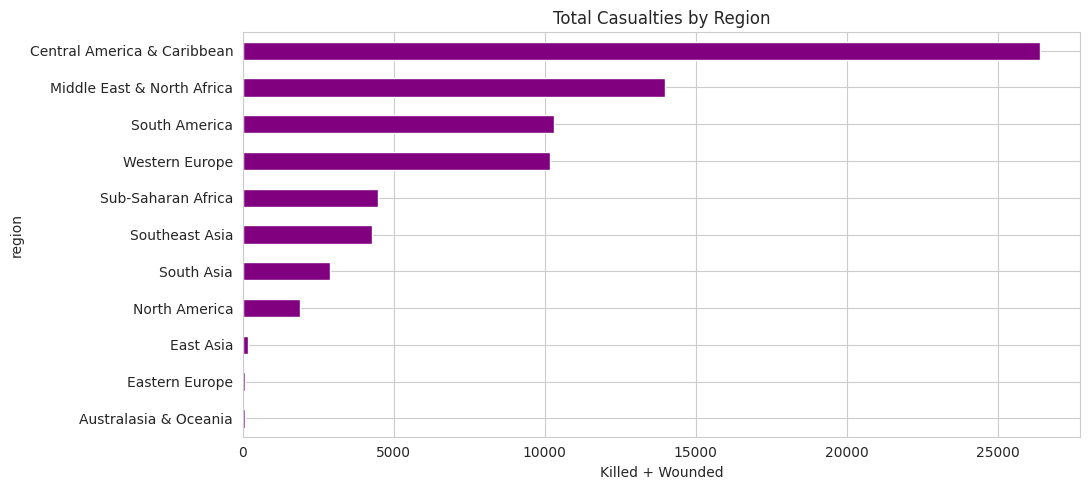

In [8]:
# ── Step 5: EDA + Visualizations ──────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)

# 1) Attacks over time
plt.figure()
data.groupby("year").size().plot(kind="line", marker="o", color="crimson")
plt.title("Terrorist Attacks Over Time")
plt.xlabel("Year"); plt.ylabel("Number of Attacks")
plt.tight_layout(); plt.show()

# 2) Top 10 countries by attack count
plt.figure()
data["country"].value_counts().head(10).plot(kind="barh", color="steelblue")
plt.title("Top 10 Countries by Number of Attacks")
plt.xlabel("Attacks"); plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()

# 3) Attacks by region
plt.figure()
data["region"].value_counts().plot(kind="bar", color="seagreen")
plt.title("Attacks by Region")
plt.xlabel(""); plt.ylabel("Attacks")
plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()

# 4) Most common attack types
plt.figure()
data["attack_type"].value_counts().plot(kind="barh", color="darkorange")
plt.title("Most Common Attack Types")
plt.xlabel("Count"); plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()

# 5) Total casualties by region
plt.figure()
(data.groupby("region")["casualties"].sum().sort_values()
     .plot(kind="barh", color="purple"))
plt.title("Total Casualties by Region")
plt.xlabel("Killed + Wounded")
plt.tight_layout(); plt.show()